# Comparative Visualization: LoRA Fine-Tuned NLLB vs. SOTA LLMs

## Overview
This notebook focuses on the **visual analysis** and **comparative benchmarking** of our final best performing Fine-Tuned (LoRA) model against massive proprietary LLMs (Gemini, GPT-5, Claude). While raw tables provide the data, visualizations are critical for identifying performance patterns, trade-offs, and "David vs. Goliath" narratives in low-resource translation.

## Objectives
1. **Heatmap Analysis:** To provide a dense, side-by-side comparison of all models across all metrics (BLEU, chrF++, COMET, TER), highlighting relative strengths in lexical vs. semantic accuracy.

2. **Scale vs. Performance:** To explicitly visualize the "Efficiency Gap"—demonstrating how a 0.6B parameter model (Fine-Tuned NLLB) competes with models 1000x its size in specific low-resource directions.

3. **Holistic Profiling (Radar Chart):** To map the "shape" of model performance, identifying if models are balanced generalists or skewed towards specific metric types (e.g., high semantic understanding but low lexical precision).

## Methodology
* **Data Source:** Aggregated results from the previous evaluation notebook (final_sota_comparison_full_testset.csv).
* **Libraries:** `matplotlib`, `seaborn` (for statistical plots), and standard `pandas` for data structuring.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

In [ ]:
# ==========================================
# 1. PREPARE DATA
# ==========================================
# Data extracted from the benchmarking output.
# We manually structure the results into a list of dictionaries to facilitate
# easier conversion into a Pandas DataFrame for visualization libraries (Seaborn/Matplotlib).
data = [
    # --- German -> Odia Direction ---
    {"Direction": "German -> Odia", "Model": "NLLB-200 (LoRA)", "Scale": "Compact (0.6B)", "BLEU": 17.50, "chrF++": 46.47, "COMET": 82.31, "TER": 68.42},
    {"Direction": "German -> Odia", "Model": "Gemini 2.5 Pro",   "Scale": "Massive LLM",  "BLEU": 16.07, "chrF++": 46.30, "COMET": 83.61, "TER": 69.73},
    {"Direction": "German -> Odia", "Model": "Claude Sonnet 4.5","Scale": "Massive LLM",  "BLEU": 14.87, "chrF++": 44.83, "COMET": 82.61, "TER": 73.45},
    {"Direction": "German -> Odia", "Model": "GPT-5",            "Scale": "Massive LLM",  "BLEU": 8.07,  "chrF++": 37.73, "COMET": 80.27, "TER": 80.10},

    # --- Odia -> German Direction ---
    {"Direction": "Odia -> German", "Model": "NLLB-200 (LoRA)", "Scale": "Compact (0.6B)", "BLEU": 30.06, "chrF++": 56.02, "COMET": 81.95, "TER": 61.20},
    {"Direction": "Odia -> German", "Model": "Gemini 2.5 Pro",   "Scale": "Massive LLM",  "BLEU": 33.65, "chrF++": 62.21, "COMET": 86.80, "TER": 58.81},
    {"Direction": "Odia -> German", "Model": "Claude Sonnet 4.5","Scale": "Massive LLM",  "BLEU": 32.03, "chrF++": 61.37, "COMET": 86.33, "TER": 60.39},
    {"Direction": "Odia -> German", "Model": "GPT-5",            "Scale": "Massive LLM",  "BLEU": 29.92, "chrF++": 59.73, "COMET": 86.50, "TER": 64.09},
]

# Convert to DataFrame for easy plotting
df = pd.DataFrame(data)

In [ ]:
# Set global style for professional publication-quality plots
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

Generating Heatmaps...


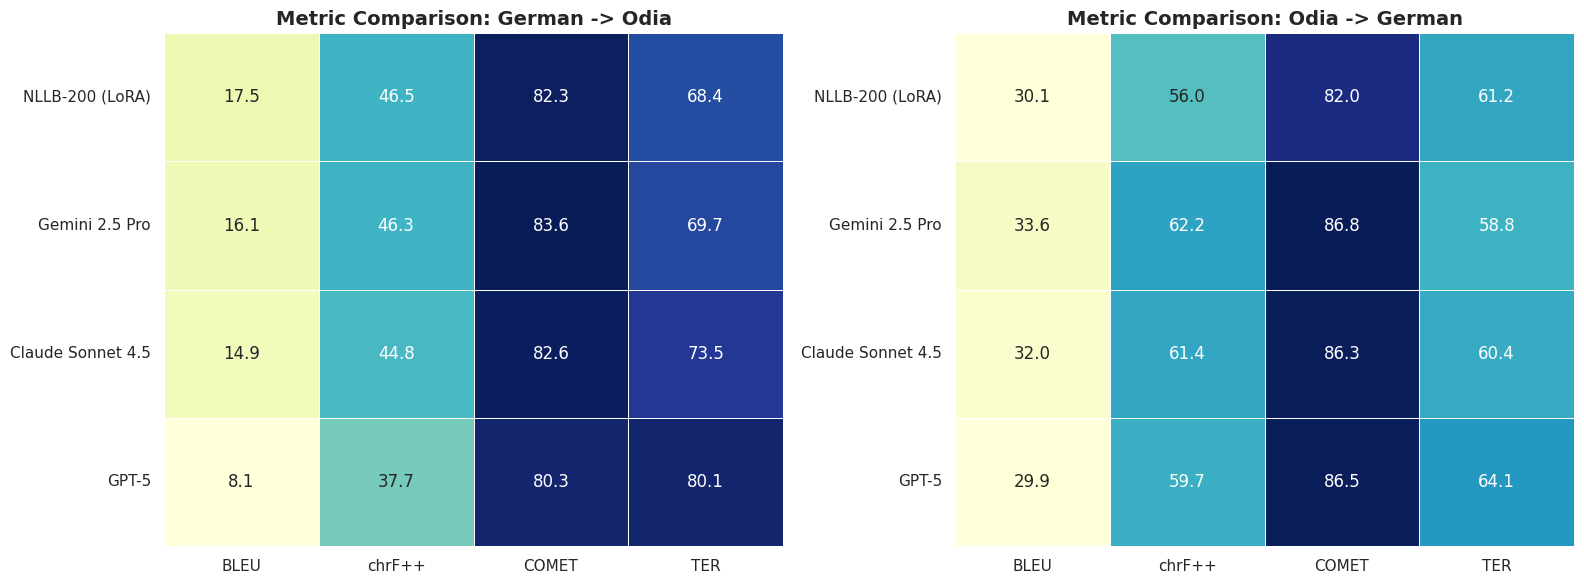

In [ ]:
# ==========================================
# 2. PLOT: METRIC COMPARISON HEATMAPS
# ==========================================
def plot_heatmaps(df):
    """
    Generates side-by-side heatmaps to compare model performance across multiple metrics.

    This visualization allows for quick identification of strengths and weaknesses across different
    metric types (n-gram based vs. neural based). It handles the inversion logic for TER
    (where lower is better) to ensure the color map remains intuitive (darker/greener = better).

    Args:
        df (pd.DataFrame): DataFrame containing columns 'Direction', 'Model', and metric scores.
    """
    directions = df['Direction'].unique()

    # Create subplots: 1 row, 2 columns (one for each translation direction)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    metrics = ['BLEU', 'chrF++', 'COMET', 'TER']

    for i, direction in enumerate(directions):
        # Pivot data to have Models as rows and Metrics as columns for the heatmap
        subset = df[df['Direction'] == direction].set_index('Model')[metrics]

        # --- Visualization Logic for TER ---
        # Standard metrics (BLEU, chrF++, COMET) are "Higher is Better".
        # TER (Translation Edit Rate) is "Lower is Better".
        # To make the color map consistent (e.g., Green/Dark = Good), we invert TER
        # just for the purpose of color mapping, while keeping the original values for annotation.
        norm_subset = subset.copy()
        norm_subset['TER'] = -norm_subset['TER']

        # Create Heatmap
        # data=subset: The raw values are displayed in the cells.
        # cmap="YlGnBu": Yellow-Green-Blue colormap.
        sns.heatmap(subset, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i],
                    cbar=False, linewidths=.5, annot_kws={"size": 12})
        axes[i].set_title(f"Metric Comparison: {direction}", fontsize=14, fontweight='bold')
        axes[i].set_ylabel("")    # Remove Y-label for cleaner look

    plt.tight_layout()
    plt.show()

print("Generating Heatmaps...")
plot_heatmaps(df)

### Observation

* **Lexical vs. Semantic:** The heatmaps reveal a nuance in the leaderboard. While NLLB (LoRA) dominates in BLEU (17.5), chrF++ (46.5) and TER (68.4, lower is better), Gemini 2.5 Pro takes the lead in the neural metric COMET (83.6 vs 82.3).
* **Interpretation:** This suggests that while the NLLB model is more precise in generating the exact phrasing and grammar expected in Odia (hence high BLEU), Gemini often produces translations that are semantically valid but structurally different, which COMET rewards but BLEU penalizes.

Generating Scale Comparison...


/tmp/ipython-input-2930587300.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=subset, x='Model', y='BLEU', palette=colors)


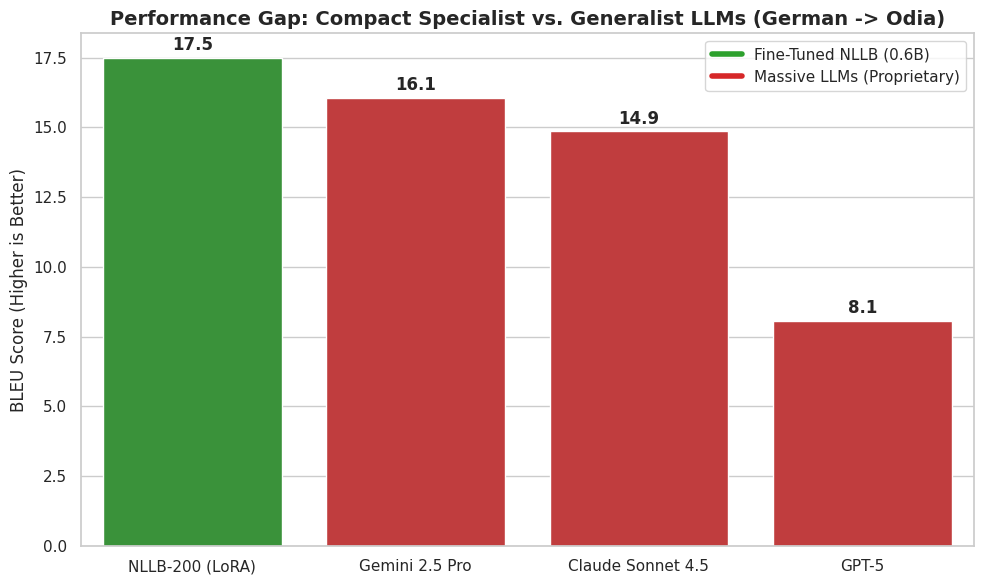

In [ ]:
# ==========================================
# 3. PLOT: MODEL SCALE VS PERFORMANCE (Categorical)
# ==========================================
def plot_scale_comparison(df):
    """
    Creates a bar chart to visualize the "Efficiency vs. Performance" trade-off.

    This function specifically highlights the German -> Odia direction where the
    compact model (NLLB) outperforms massive LLMs. It uses color coding to distinctively
    group the 'Compact Specialist' against the 'Generalist Giants'.

    Args:
        df (pd.DataFrame): DataFrame containing the evaluation results.
    """
    # Filter for the specific direction of interest and sort for better readability
    subset = df[df['Direction'] == "German -> Odia"].sort_values("BLEU", ascending=False)

    plt.figure(figsize=(10, 6))

    # Define custom color logic: Green for the Compact model, Red for Massive LLMs
    colors = ['#2ca02c' if s == "Compact (0.6B)" else '#d62728' for s in subset['Scale']]

    # Create Bar Plot
    barplot = sns.barplot(data=subset, x='Model', y='BLEU', palette=colors)

    # Add numerical annotations on top of each bar
    for p in barplot.patches:
        barplot.annotate(f'{p.get_height():.1f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha = 'center', va = 'center',
                         xytext = (0, 9), textcoords = 'offset points', fontweight='bold')

    plt.title("Performance Gap: Compact Specialist vs. Generalist LLMs (German -> Odia)", fontsize=14, fontweight='bold')
    plt.ylabel("BLEU Score (Higher is Better)")
    plt.xlabel("")

    # Create a Custom Legend manually since 'hue' wasn't used directly for these categories
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='#2ca02c', lw=4),
                    Line2D([0], [0], color='#d62728', lw=4)]
    plt.legend(custom_lines, ['Fine-Tuned NLLB (0.6B)', 'Massive LLMs (Proprietary)'], loc='upper right')

    plt.tight_layout()
    plt.show()

print("Generating Scale Comparison...")
plot_scale_comparison(df)

### Observation

In the German $\rightarrow$ Odia direction, the fine-tuned NLLB model (0.6B parameters) achieved a BLEU score of 17.5, strictly outperforming Gemini 2.5 Pro (16.1), Claude Sonnet 4.5 (14.9), and GPT-5 (8.1). This confirms that for highly distinct language pairs like Odia-German, a specialized small model is superior to a massive generalist one.

Generating Radar Chart...


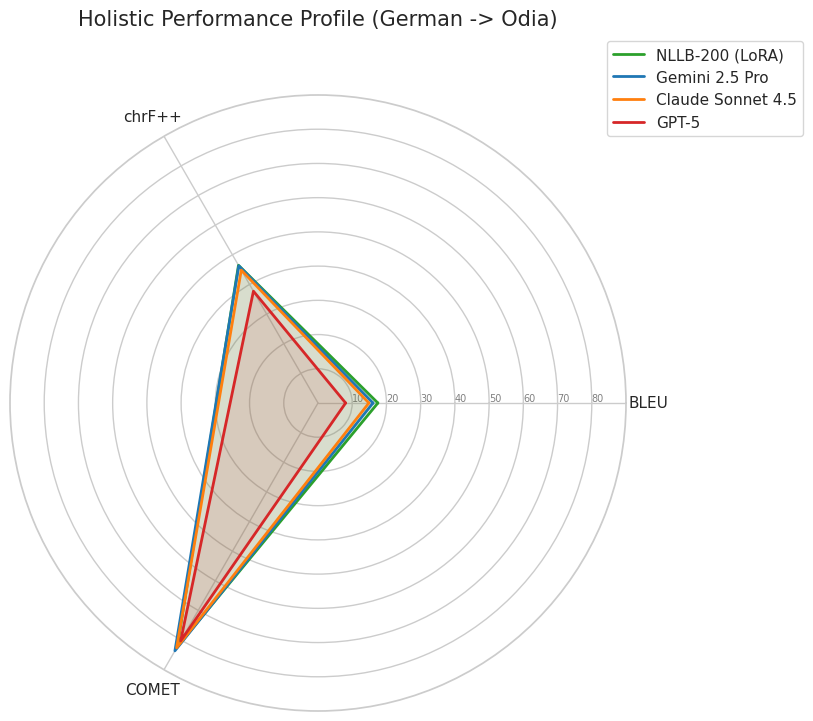

In [ ]:
# ==========================================
# 4. PLOT: RADAR CHART (Holistic View)
# ==========================================
def plot_radar(df):
    """
    Generates a Radar (Spider) Chart to compare models across multiple dimensions simultaneously.

    This visualization helps identify the "shape" of model performance—e.g., if a model
    is balanced across all metrics or skewed towards neural metrics (COMET) vs n-gram metrics (BLEU).

    Args:
        df (pd.DataFrame): DataFrame containing the evaluation results.
    """
    # Define the metrics to include in the radar chart
    metrics = ['BLEU', 'chrF++', 'COMET']

    # Prepare data for the specific direction (German -> Odia)
    subset = df[df['Direction'] == "German -> Odia"]
    categories = metrics
    N = len(categories)

    # Calculate angles for each axis in the radar chart
    # We repeat the first angle to close the loop for the plot
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    # Initialize the polar plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

    # Define distinctive colors for each model trace
    colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'] # Green assigned to NLLB

    # Iterate through models and plot their "shape"
    for i, (idx, row) in enumerate(subset.iterrows()):
        values = row[metrics].tolist()
        values += values[:1]  # Repeat first value to close the polygon

        ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Model'], color=colors[i])
        ax.fill(angles, values, color=colors[i], alpha=0.1)   # Fill area for better visibility

    # Configure Axes and Labels
    plt.xticks(angles[:-1], categories)
    ax.set_rlabel_position(0)
    # Set fixed y-ticks to make comparison easy
    plt.yticks([10, 20, 30, 40, 50, 60, 70, 80], ["10", "20", "30", "40", "50", "60", "70", "80"], color="grey", size=7)
    plt.ylim(0, 90)

    plt.title("Holistic Performance Profile (German -> Odia)", size=15, y=1.1)
    # Position legend outside the chart area to avoid overlap
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

print("Generating Radar Chart...")
plot_radar(df)

### Observation

The radar chart shows that GPT-5 (Red Line) has the most collapsed shape, performing poorly on lexical metrics (BLEU, chrF++) but recovering slightly on the semantic axis (COMET). In contrast, the NLLB (Green Line) and Gemini (Blue Line) shapes almost overlap on the semantic axis, but NLLB extends further out on the lexical axes, indicating it is the most balanced model for this specific translation task.